In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import svm
#from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_validate, GridSearchCV, KFold, cross_val_score
#from sklearn.metrics import recall_score

#from sklearn import preprocessing
from sklearn.preprocessing import RobustScaler, StandardScaler



In [3]:
INPUT_DIR        = "data/input"
MODEL_INPUT_DIR  = f"{INPUT_DIR}/formatted-input"
#MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/model_input_traintest_cleavedSelf9k_hex_noID.csv"#model_input_traintest_randselfpeps_commonAlleles_nomhcnuggs_newPath.csv"#model_input_traintest_randselfpeps_new_pathogenicity.csv"#" #"model_input_imm_and_mhc-nb_m1_t7.csv"#"#"model_input_all_traintest.csv"
#MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/model_input_traintest_cleavedself9k_di_selfNoID.csv"
MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/traintest_9kcleavedself_featureTable.csv"
#MODEL_INPUT_FILE = f"data/selfsimilarity/selfsim_noID_combined.csv"
#FEATURE_TABLE    = f"{MODEL_INPUT_DIR}/featureTable1.csv"
#MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/testMTEC_raw_featureTable_traintest_9kcleavedself.csv"

#ALL_PEPS_FILE    = f"{INPUT_DIR}/cedar_randself_mhc-nbs.txt"

IMM_PEP_FILE     = f"{INPUT_DIR}/cedar_imm_peps_traintest.txt"#cedar_imm_9mers.txt"  #cedar_Immunogenic_self_df.txt"        #cedar_imm_peps_traintest.txt"

#NON_IMM_PEP_FILE = f"{INPUT_DIR}/9kcleavedrandselfpeps.txt"#cedar_non-imm_9mers.txt"##randselfpeps~10k.txt"#cedar_non-imm_and_self_55.txt"#" #" #cedar_non_imm_peps_traintest.txt" #" #" randselfpeps~10k.txt cedar_non-imm_and_self_10    #"#randselfpeps~10k.txt"#random_in_silico_peptides.txt"#non_mhc_binding_peptides.txt"#"
NON_IMM_PEP_FILE = f"{INPUT_DIR}/cedar_non_imm_peps_traintest.txt"
#NON_IMM_PEP_FILE = f"{INPUT_DIR}/non-imm_9kcleavedselfpeps.txt"
#NON_IMM_PEP_FILE = f"{INPUT_DIR}/non-imm_4200-binding-cleavedselfpeps.txt"
#NON_IMM_PEP_FILE = f"{INPUT_DIR}/non-imm_4600-non-binding-cleavedselfpeps.txt"
#NON_IMM_PEP_FILE = f"{INPUT_DIR}/non-imm_2200-weakbinders-cleavedselfpeps.txt"

# TESTING NEW PEP SET
#IMM_PEP_FILE     = f"{INPUT_DIR}/cedar_maybe_imm.txt"
#NON_IMM_PEP_FILE = f"{INPUT_DIR}/cedar_maybe_non_imm.txt"
# ENDING TESTING

NON_IMM_LABEL = "Non Imm"
TRAINING_SET = "Imm_Non-Imm"

# VALIDATION_MODEL_INPUT_FILE =  f"{MODEL_INPUT_DIR}/model_input_hormad1-magea4.csv"
# VALIDATION_PEPTIDES_FILE = f"{INPUT_DIR}/hormad1-magea4_cleavedPeps.txt"

MODEL_SAVING_DIR = None
if TRAINING_SET != "":
    MODEL_SAVING_DIR = f"saved_models/{TRAINING_SET}"

## Load the Data

In [4]:
X_df = pd.read_csv(MODEL_INPUT_FILE)
#X_df = pd.read_csv(FEATURE_TABLE)
#display(X_df[X_df['peptide'].str.contains('pep')])

#X_validation_df = pd.read_csv(VALIDATION_MODEL_INPUT_FILE)

X_df.drop_duplicates(subset=['peptide'], inplace=True)
X_df.sort_values(by='peptide', inplace=True)

display(X_df)
display(X_df.shape)

,peptide,best_rank,avg_rank,strong_binders_count,weak_binders_count,best_netmhc_r,netmhc_a,best_mixmhc_r,mixmhc_a,best_mhcflurry_r,...,di_avg_score,di_best_a_score,di_avg_a_score,di_best_b_score,di_avg_b_score,di_best_c_score,di_avg_c_score,PRIME_%Rank_bestAllele,similarity_score,tap_score
0,AAAAAAGVL,0.018,0.118000,13,25,0.255,HLA-C03:03,0.018,HLA-C03:03,0.081,...,0.825294,0.828742,0.654142,0.971572,0.865091,0.981934,0.908443,0.065,0.929204,0.5886
1,AAAAAAQQIQV,0.279,2.195000,1,2,5.282,HLA-A68:02,0.279,HLA-B51:08,1.024,...,0.782432,0.896026,0.623338,0.949169,0.805331,0.978184,0.870685,2.832,0.910891,0.4028
2,AAAAAAVAA,0.043,0.304667,6,12,0.690,HLA-B55:01,0.043,HLA-B45:01,0.181,...,0.837527,0.903314,0.692634,0.974613,0.863879,0.988599,0.913626,0.225,0.945455,0.3309
3,AAAAAGVSFTK,0.015,0.116333,6,15,0.272,HLA-A11:02,0.062,HLA-A03:02,0.015,...,0.796717,0.768044,0.669235,0.926138,0.831741,0.965046,0.854463,0.510,0.841608,0.7572
4,AAAAAPTTT,0.121,1.335333,2,10,3.244,HLA-B55:01,0.121,HLA-C12:04,0.641,...,0.807937,0.819793,0.638820,0.957885,0.837552,0.990274,0.897649,0.280,0.890566,0.7740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29293,YYVFHMPRCL,0.104,0.384667,0,9,0.635,HLA-C14:02,0.104,HLA-C14:03,0.415,...,0.650844,0.613803,0.357014,0.912071,0.723215,0.935935,0.790444,0.922,0.680435,0.7886
29294,YYVGYLQPRTF,0.014,0.047000,7,10,0.046,HLA-A24:03,0.014,HLA-C14:03,0.081,...,0.727760,0.782766,0.433589,0.964172,0.815213,0.974230,0.855855,0.758,0.890595,0.9316
29295,YYVHEGIRTY,0.005,0.015000,15,28,0.033,HLA-A26:01,0.005,HLA-C07:02,0.007,...,0.813675,0.934456,0.657942,0.972838,0.866823,0.988775,0.876161,0.566,0.813725,0.9371
29296,YYYAGSSRL,0.003,0.011000,14,30,0.003,HLA-C14:02,0.019,HLA-C14:02,0.011,...,0.731406,0.714564,0.506022,0.895387,0.832721,0.966470,0.802863,0.358,0.861314,0.7838


(29298, 24)

Adding Length feature and Dropping Non-Informative features from the featureTable

In [5]:
X_df['length'] = X_df['peptide'].str.len()

print(f"Model Train Test DF: {X_df.shape}")

X_df = X_df.drop(columns=['best_allele', 'best_netmhc_r', 'best_mixmhc_r', 'best_mhcflurry_r', 'best_mhcnuggets_r', 
       'netmhc_a', 'mixmhc_a', 'mhcflurry_a', 'mhcnuggets_a'], errors='ignore')

# NB Drops: TAP, selfsimilarity, All Num Tools, di_avg
X_df = X_df.drop(columns=['Num_Tools_Super_Strong_Binder', 'Num_Tools_Strong_Binder',
       'Num_Tools_Weak_Binder', 'Num_Tools_Super_Weak_Binder', 'Num_Tools_0_01', 'tap_score',
       'Num_Tools_0_02', 'Num_Tools_0_03', 'Num_Tools_0_04', 'strong_binders_count','Num_Tools_1', 
       'Num_Tools_2', 'best_netmhc_r', 'best_mixmhc_r', 'best_mhcflurry_r', 'best_mhcnuggets_r', 'di_avg_score', 'di_best_a_score',
       'di_best_b_score', 'di_best_c_score',
       'di_avg_a_score', 'di_avg_b_score', 'di_avg_c_score', 'selfsimilarity', 'similarity_score', 'Num_Tools_0_05', 'Num_Tools_0_10', 
       'Num_Tools_0_50'], errors='ignore')

X_df = X_df.drop(columns=['best_rank'], errors='ignore')

## TESTING NEW FEATURE SET
# X_df = X_df.drop(columns=['avg_rank', 'di_avg_score', 'Num_Tools_0_05',
#        'Num_Tools_0_10', 'Num_Tools_0_50'], errors='ignore')

## DONE TESTING

FINAL_FEATURES = X_df.drop(columns='peptide').columns
print(f"Final set of features ({len(FINAL_FEATURES)})")

display(FINAL_FEATURES)

Model Train Test DF: (29298, 25)
Final set of features (7)


Index(['avg_rank', 'weak_binders_count', 'mtec_expression_count',
       'pathogenicity', 'di_best_score', 'PRIME_%Rank_bestAllele', 'length'],
      dtype='str')

In [6]:
immPeps, non_immPeps = set(), set()

def addPeps(fp: str, pepSet: set):
    with open(fp, 'r') as f:
        for line in f:
            if line:
                pepSet.add(line.strip())

addPeps(IMM_PEP_FILE, immPeps)
addPeps(NON_IMM_PEP_FILE, non_immPeps)

labels_df = pd.DataFrame([
    {'peptide': pep, 'immunogenic': 1} for pep in immPeps
] + [
    {'peptide': pep, 'immunogenic': 0} for pep in non_immPeps
])

labels_df.sort_values(by='peptide', inplace=True)
labels_df.drop_duplicates(subset=['peptide'], inplace=True)

labels_to_drop = set(labels_df['peptide']) - set(X_df['peptide'])
labels_df = labels_df[~labels_df['peptide'].isin(labels_to_drop)]

display(labels_df.head(3))
display(labels_df.tail(3))

# Ensure peptides in feature df match those in the label df
label_peps = immPeps.copy()
label_peps.update(non_immPeps)
X_df = X_df[X_df['peptide'].isin(label_peps)]

print(f"Immunogenic: {len(immPeps)}")
print(f"{NON_IMM_LABEL} set: {len(non_immPeps)}")

,peptide,immunogenic
9580,AAAAAAGVL,1
13536,AAAAAAQQIQV,0
6041,AAAAAAVAA,1


,peptide,immunogenic
7646,YYVHEGIRTY,1
5982,YYYAGSSRL,1
11824,YYYRFVIGL,0


Immunogenic: 9663
Non Imm set: 9836


#### 8mer missingness

In [7]:
print(f"Num 8mers in set with NaN for deepimmuno: {X_df[X_df['di_best_score'].isna()].shape[0]}")

Num 8mers in set with NaN for deepimmuno: 790


Create Dataframes for HLA Binder, PRIME and DeepImmuno Only Features

In [25]:
# PRIME_df = X_df[['peptide', 'PRIME_%Rank_bestAllele']]
# DEEPIMMUNO_df = X_df[['peptide', 'di_best_score', 'di_avg_score', 'di_best_a_score', 'di_best_b_score', 'di_best_c_score']]
# HLABINDER_df = X_df[['peptide', 'hla_best_rank', 'avg_rank', 'weak_binders_count',
#                     'Num_Tools_0_05', 'Num_Tools_0_10', 'Num_Tools_0_50']]

#### Get numpy array

In [8]:
X = X_df.drop(columns='peptide').to_numpy()
# display(X)
# X = PRIME_df.drop(columns='peptide').to_numpy()
# FINAL_FEATURES = ['PRIME_%Rank_bestAllele']
# display(X)

y = labels_df.drop(columns='peptide').to_numpy()
y=y.ravel()
display(y)

array([1, 0, 1, ..., 1, 1, 0], shape=(19499,))

In [9]:
print(X.dtype)
#print(X_df_final.drop(columns='peptide').dtypes)

float64


In [10]:
assert len(X_df) == X.shape[0] == len(y)

# Models

In [11]:
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn import svm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import fbeta_score, make_scorer


# ==================================================================
# Shared CV folds
# ------------------------------------------------------------------
# Composite stratification key: class label + exact peptide length.
# Computed once and reused for every model group so all models are
# evaluated on identical train/test splits (fair comparison).
# ==================================================================
assert len(X_df) == X.shape[0] == len(y)  # sanity check alignment

lengths = X_df["length"].to_numpy()
strata = pd.Series(y).astype(str) + "_" + pd.Series(lengths).astype(str)

N_SPLITS = 5
N_REPEATS = 2
#_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
_cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)
CV_FOLDS = list(_cv.split(X, strata))

SCORING = {
    "precision" : "precision",
    "recall" : "recall",
    "roc_auc" : "roc_auc",
    "avg_precision" : "average_precision",
    "f0.5": make_scorer(fbeta_score, beta=0.5),
}
REFIT_METRIC = "precision"


# ==================================================================
# run_model: single entry point for fitting + collecting fold scores
# ==================================================================
def run_model(model_name, pipe, X, y, cv_folds=CV_FOLDS, scoring=SCORING,
              param_grid=None, refit_metric=REFIT_METRIC):
    """
    Fit `pipe` on (X, y) using precomputed `cv_folds` and return a tidy
    per-fold, per-metric results dataframe with columns:
    model, fold, metric, score, params.

    - param_grid given  -> GridSearchCV; best config chosen by refit_metric,
                            per-fold scores recorded for that best config.
    - param_grid=None   -> single cross_validate pass using `pipe` exactly
                            as given (use this once you've already fixed
                            the hyperparameters, e.g. after a prior search).

    All preprocessing (imputation, scaling) should live inside `pipe`
    itself so it's refit fold-by-fold and never leaks across folds.
    """
    print('='*60)
    print(f'Running {model_name}')
    results = []

    if param_grid is not None:
        clf = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=cv_folds,
            scoring=scoring,
            refit=refit_metric,
            n_jobs=-1,
            return_train_score=True,
        )
        clf.fit(X, y)
        best_index = clf.best_index_
        params_str = str(clf.best_params_)

        for metric_name in scoring:
            fold_scores = [
                clf.cv_results_[f"split{i}_test_{metric_name}"][best_index]
                for i in range(len(cv_folds))
            ]
            for fold_idx, score in enumerate(fold_scores):
                results.append({
                    "model": model_name,
                    "fold": fold_idx,
                    "metric": metric_name,
                    "score": score,
                    "params": params_str,
                })

        print(f"Done: {model_name} (best params: {clf.best_params_})")

    else:
        scores = cross_validate(
            estimator=pipe,
            X=X,
            y=y,
            cv=cv_folds,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=True,
        )
        params_str = str(pipe.get_params())

        for metric_name in scoring:
            for fold_idx, score in enumerate(scores[f"test_{metric_name}"]):
                results.append({
                    "model": model_name,
                    "fold": fold_idx,
                    "metric": metric_name,
                    "score": score,
                    "params": params_str,
                })

        print(f"Done: {model_name} (fixed params)")

    return pd.DataFrame(results)

In [51]:
# ==================================================================
# plotModels: combine any number of results dataframes, one panel
# per metric, one coloured box per model
# ==================================================================
def plotModels(results_dfs):
    combined = pd.concat(results_dfs, ignore_index=True)
    metrics = combined["metric"].unique()
    n_metrics = len(metrics)

    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5), sharey=True)
    if n_metrics == 1:
        axes = [axes]

    for ax, metric_name in zip(axes, metrics):
        subset = combined[combined["metric"] == metric_name]

        sns.boxplot(data=subset, x="model", y="score", hue="model",
                    ax=ax, legend=False)
        sns.stripplot(data=subset, x="model", y="score",
                      color="black", size=5, alpha=0.6, ax=ax)

        ax.set_title(metric_name)
        ax.set_xlabel("")
        ax.set_ylabel("score" if ax == axes[0] else "")
        ax.tick_params(axis="x", rotation=45)

    plt.suptitle("Model performance by metric — 5-fold CV, params selected by precision")
    plt.tight_layout()
    plt.savefig(f'{MODEL_SAVING_DIR}/models_cv_metrics.png')
    plt.show()

# ==================================================================
# plotModelsMean: same combine-and-facet-by-metric logic as plotModels,
# but summarised to one bar (mean) per model per metric, with error bars.
# ==================================================================
def plotModelsMean(results_dfs, error_bars="sd", capsize=0.15):
    """
    error_bars: passed to seaborn's `errorbar` argument.
        "sd" (default) -> standard deviation of fold scores (recommended
                           with small n=5 folds; doesn't overstate confidence)
        "se"           -> standard error of the mean
        None           -> no error bars
    (Requires seaborn >= 0.12; on older seaborn use `ci="sd"` instead.)
    """
    combined = pd.concat(results_dfs, ignore_index=True)
    metrics = combined["metric"].unique()
    n_metrics = len(metrics)
 
    # Fixed y-axis range across all panels (sharey=True), starting close to
    # the worst observed score rather than 0, with a little padding.
    y_min, y_max = combined["score"].min(), combined["score"].max()
    padding = (y_max - y_min) * 0.1
    y_lower, y_upper = y_min - padding, y_max + padding
 
    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5), sharey=True)
    if n_metrics == 1:
        axes = [axes]
 
    for ax, metric_name in zip(axes, metrics):
        subset = combined[combined["metric"] == metric_name]
 
        sns.barplot(data=subset, x="model", y="score", hue="model",
                    ax=ax, legend=False, errorbar=error_bars, capsize=capsize,
                    width=0.6)  # 3/4 of seaborn's default width (0.8)
 
        ax.set_title(metric_name)
        ax.set_xlabel("")
        ax.set_ylabel("mean score" if ax == axes[0] else "")
        ax.tick_params(axis="x", rotation=45)
 
    axes[0].set_ylim(y_lower, y_upper)  # shared across all axes via sharey=True
 
    plt.suptitle("Mean model performance by metric — 5-fold CV, error bars = " +
                 (error_bars if error_bars else "none"))
    plt.tight_layout()
    plt.savefig(f'{MODEL_SAVING_DIR}/models_mean_metrics.png')
    plt.show()
   

Logistic Regression

In [63]:
# --- Logistic regression: scaled internally -----------------------
pipe_logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(random_state=0, max_iter=5000, class_weight="balanced")),
])
param_grid_logreg = {"clf__C": [0.1, 1, 5, 10]}

results_logreg_df = run_model("logreg", pipe_logreg, X, y, param_grid=param_grid_logreg)
# ============================================================
# Running logreg
# Done: logreg (best params: {'clf__C': 0.1})
# 5x2 fold CV for Imm | Rand

Running logreg
Done: logreg (best params: {'clf__C': 0.1})


SVM

In [64]:
# ==================================================================
# Model groups — data used is always the raw X; scaling/imputation
# (where needed) happens inside each pipeline, fold-internally.
# ==================================================================

# --- SVM: linear + RBF, scaled internally ------------------------
pipe_svm_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
    ("scaler", RobustScaler()),
    ("svc", svm.LinearSVC(random_state=0, max_iter=10000)),
])
pipe_svm_rbf = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
    ("scaler", RobustScaler()),
    ("svc", svm.SVC(kernel="rbf", random_state=0)),
])

# GridSearchCV to find best parameters for each model
param_grid_linear = {"svc__C": [0.1, 1, 5, 10, 100]}
param_grid_rbf = {"svc__C": [0.1, 1], "svc__gamma": [0.01, 0.1, 1]}

results_svm_linear_df = run_model("svm_linear", pipe_svm_linear, X, y,
                                   param_grid=param_grid_linear)
# results_svm_rbf_df = run_model("svm_rbf", pipe_svm_rbf, X, y,
#                                 param_grid=param_grid_rbf)
# ============================================================
# Running svm_linear
# Done: svm_linear (best params: {'svc__C': 5})
# ============================================================
# Running svm_rbf
# Done: svm_rbf (best params: {'svc__C': 1, 'svc__gamma': 0.01})
# New metrics across 10 folds:
# Running svm_rbf (10 fold CV with precision replacing macro)
# Done: svm_rbf (best params: {'svc__C': 0.1, 'svc__gamma': 1})

# Using best SVM with fixed parameters
pipe_svm_rbf_fixed = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
    ("scaler", RobustScaler()),
    ("svc", svm.SVC(kernel="rbf", C=0.1, gamma=1, random_state=0)),
])
results_svm_rbf_df = run_model("svm_rbf", pipe_svm_rbf_fixed, X, y,
                                param_grid=None)

Running svm_linear
Done: svm_linear (best params: {'svc__C': 0.1})
Running svm_rbf
Done: svm_rbf (fixed params)


Tree-based models

In [65]:
# --- Tree-based: RF (needs imputer) + HGB (native NaN handling) --
pipe_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
    ("clf", RandomForestClassifier(random_state=0, class_weight="balanced", n_jobs=1)),
])
pipe_hgb = Pipeline([("clf", HistGradientBoostingClassifier(random_state=0))])

param_grid_rf = {
    "clf__n_estimators": [200, 300],
    "clf__max_depth": [20, 30, 40],
    "clf__min_samples_leaf": [1, 5],
}
param_grid_hgb = {
    "clf__max_iter": [100, 200],
    "clf__max_depth": [10, 20, 30],
    "clf__learning_rate": [0.05, 0.1],
}

# results_rf_df = run_model("rf", pipe_rf, X, y, param_grid=param_grid_rf)
# results_hgb_df = run_model("hgb", pipe_hgb, X, y, param_grid=param_grid_hgb)

# 10 fold CV results
# ============================================================
# Running rf
# Done: rf (best params: {'clf__max_depth': 30, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200})
# ============================================================
# Running hgb
# Done: hgb (best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 10, 'clf__max_iter': 100})

pipe_hgb_fixed = Pipeline([("clf", HistGradientBoostingClassifier(max_iter=100, learning_rate=0.05, max_depth=10, random_state=0))])
results_hgb_df = run_model("hgb", pipe_hgb_fixed, X, y, param_grid=None)

pipe_rf_fixed = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
    ("clf", RandomForestClassifier(max_depth=20, min_samples_leaf=10, n_estimators=200, random_state=0, class_weight="balanced", n_jobs=1)),
])
results_rf_df = run_model("rf", pipe_rf_fixed, X, y, param_grid=None)

Running hgb
Done: hgb (fixed params)
Running rf
Done: rf (fixed params)


Plotting Results

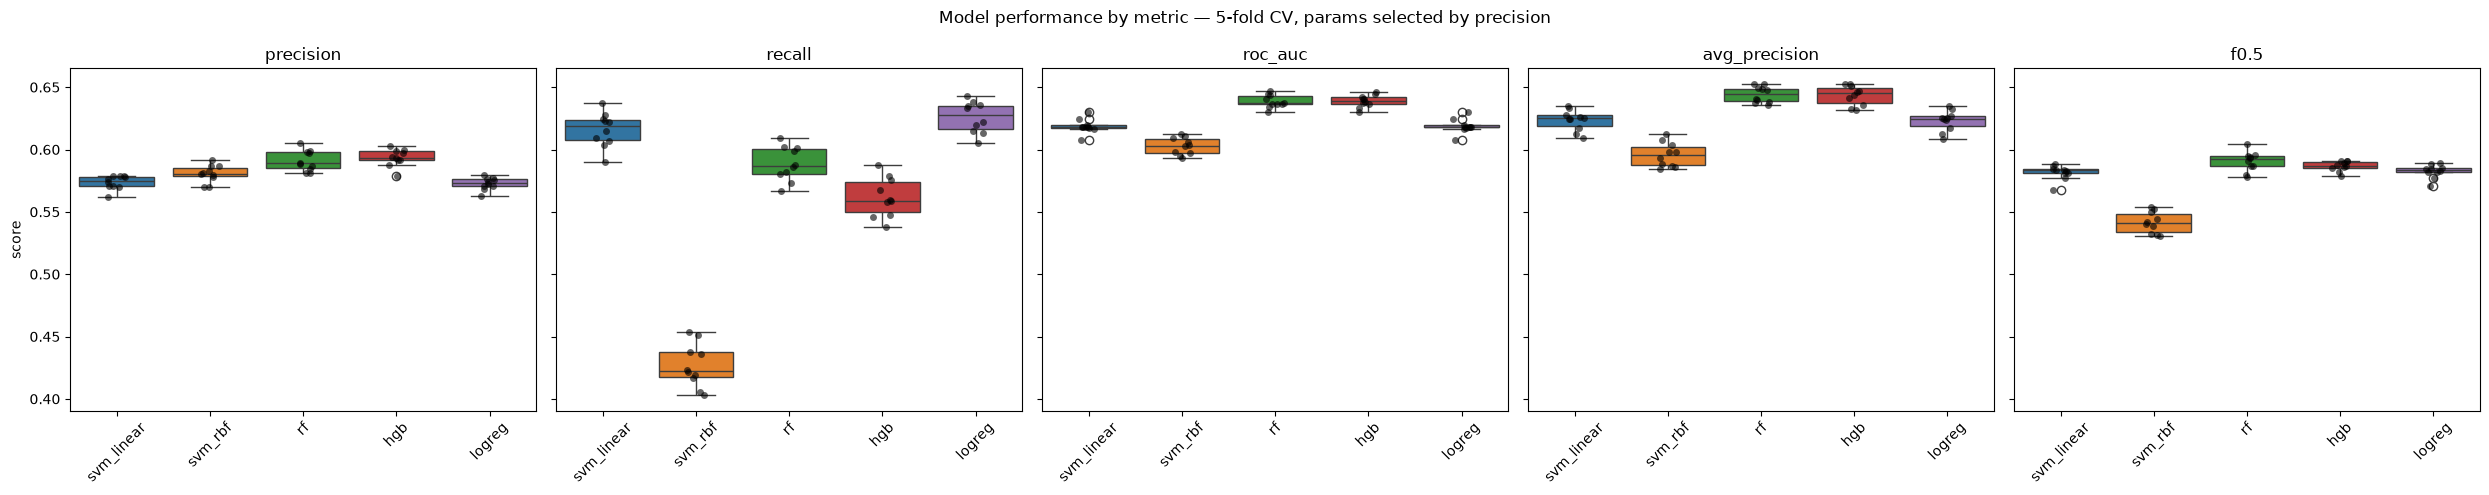

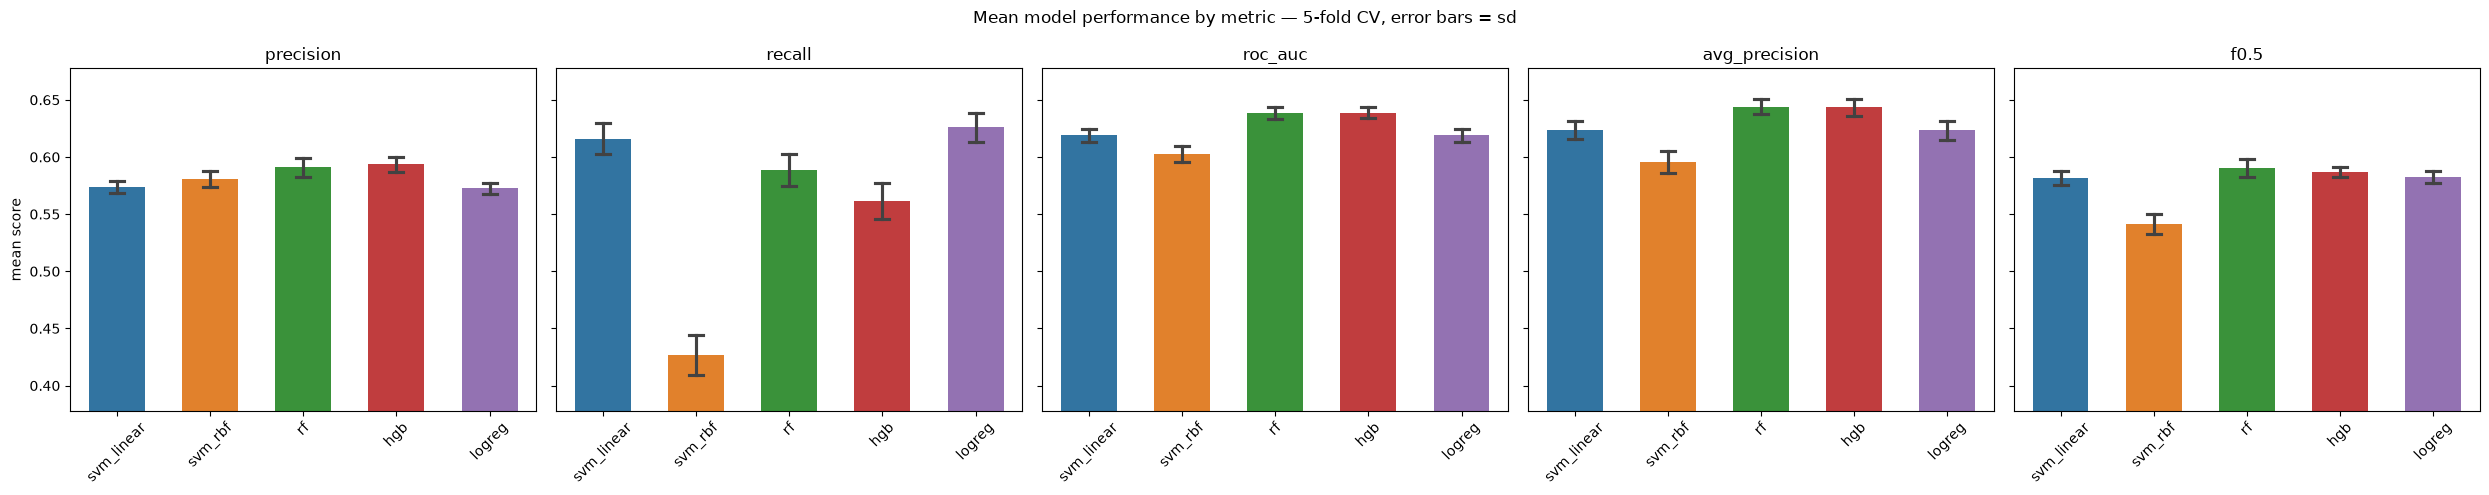

In [66]:
all_results = [
    results_svm_linear_df,
    results_svm_rbf_df,
    results_rf_df,
    results_hgb_df,
    results_logreg_df,
]

plotModels(all_results)
plotModelsMean(all_results)

In [67]:
print(pd.concat(all_results, ignore_index=True).groupby(["metric", "model"])["score"].mean())

metric         model     
avg_precision  hgb           0.643456
               logreg        0.623219
               rf            0.644143
               svm_linear    0.623633
               svm_rbf       0.595718
f0.5           hgb           0.586798
               logreg        0.582553
               rf            0.590463
               svm_linear    0.581678
               svm_rbf       0.541422
precision      hgb           0.593583
               logreg        0.572670
               rf            0.590980
               svm_linear    0.573746
               svm_rbf       0.580596
recall         hgb           0.561678
               logreg        0.625892
               rf            0.588635
               svm_linear    0.615905
               svm_rbf       0.426783
roc_auc        hgb           0.638786
               logreg        0.618839
               rf            0.638696
               svm_linear    0.618831
               svm_rbf       0.602772
Name: score, dtype: floa

Feature Importance Workflow

In [12]:
# plot_feature_clusters: diagnostic step, run BEFORE trusting any
# feature importance ranking. Hierarchical clustering on Spearman
# rank correlations reveals which features are collinear, since
# permutation importance (and MDI) split/dilute credit between
# correlated features rather than showing their true joint importance.
# Adapted from the scikit-learn "Permutation Importance with
# Multicollinear or Correlated Features" example.
# ==================================================================
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
import numpy as np
 
 
def plot_feature_clusters(X, feature_names, figsize=(14, 8), impute=True):
    """
    Plots a dendrogram + correlation heatmap (features reordered so
    correlated ones sit next to each other) side by side.
 
    impute: Spearman correlation (and the linkage built on it) requires
        finite values, so raw NaNs raise a ValueError from scipy. If True
        (default), NaNs are median-imputed *purely for this diagnostic*
        (matches the strategy your model pipelines already use) -- this
        does not touch your actual training data. Zero-variance (constant)
        columns are also dropped, since correlation is undefined for them.
 
    Returns:
        dist_linkage: linkage matrix, needed to pick a cluster threshold
                       (use this with select_uncorrelated_features)
        corr: the symmetric Spearman correlation matrix
        feature_names: names matching corr's columns (may be a subset of
                        the input if constant columns were dropped -- use
                        THIS list, not your original one, downstream)
    """
    X = np.asarray(X, dtype=float)
    feature_names = list(feature_names)
 
    if impute and np.isnan(X).any():
        n_missing = int(np.isnan(X).sum())
        print(f"plot_feature_clusters: median-imputing {n_missing} missing "
              f"value(s) for this diagnostic only (model pipelines are unaffected).")
        X = SimpleImputer(strategy="median").fit_transform(X)
 
    variances = np.var(X, axis=0)
    keep_mask = variances > 0
    kept_indices = np.flatnonzero(keep_mask)  # maps reduced-space idx -> original X column idx
    if not keep_mask.all():
        dropped = [f for f, keep in zip(feature_names, keep_mask) if not keep]
        print(f"plot_feature_clusters: dropping {len(dropped)} constant "
              f"feature(s) (correlation undefined): {dropped}")
        X = X[:, keep_mask]
        feature_names = [f for f, keep in zip(feature_names, keep_mask) if keep]
 
    corr = spearmanr(X).correlation
    corr = (corr + corr.T) / 2
    np.fill_diagonal(corr, 1)
    distance_matrix = 1 - np.abs(corr)
    dist_linkage = hierarchy.ward(squareform(distance_matrix, checks=False))
 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    dendro = hierarchy.dendrogram(dist_linkage, labels=feature_names,
                                   ax=ax1, leaf_rotation=90)
    dendro_idx = np.arange(len(dendro["ivl"]))
 
    ax2.imshow(corr[dendro["leaves"], :][:, dendro["leaves"]],
               cmap="coolwarm", vmin=-1, vmax=1)
    ax2.set_xticks(dendro_idx)
    ax2.set_yticks(dendro_idx)
    ax2.set_xticklabels(dendro["ivl"], rotation="vertical")
    ax2.set_yticklabels(dendro["ivl"])
 
    ax1.set_title("Hierarchical clustering (Spearman |corr| distance)")
    ax2.set_title("Correlation heatmap (reordered by cluster)")
    fig.tight_layout()
    plt.savefig(f'{MODEL_SAVING_DIR}/feature_correlation.png')
    plt.show()
 
    return dist_linkage, corr, feature_names, kept_indices
 
 
def select_uncorrelated_features(dist_linkage, feature_names, threshold):
    """
    Cuts the dendrogram at `threshold` (distance = 1 - |Spearman corr|,
    so e.g. threshold=0.3 groups together any features correlated at
    |corr| > 0.7) and keeps ONE representative feature per cluster.
 
    Pick `threshold` by eye from the plot_feature_clusters dendrogram —
    it's the height at which you'd "cut" the tree to separate clusters.
 
    Returns: (selected_indices, selected_feature_names)
    """
    cluster_ids = hierarchy.fcluster(dist_linkage, threshold, criterion="distance")
    cluster_to_indices = {}
    for idx, cluster_id in enumerate(cluster_ids):
        cluster_to_indices.setdefault(cluster_id, []).append(idx)
 
    selected_idx = [indices[0] for indices in cluster_to_indices.values()]
    selected_names = [feature_names[i] for i in selected_idx]
 
    print(f"{len(feature_names)} features -> {len(selected_names)} clusters "
          f"(threshold={threshold})")
    return selected_idx, selected_names
 
 
# ==================================================================
# run_permutation_importance: model-agnostic, works identically for
# every model type (RF/HGB/SVM linear/SVM rbf/logreg). Refits on each
# CV training fold and measures the drop in `scoring` on that fold's
# held-out test data when each feature is shuffled — consistent with
# how every other metric in this script is evaluated.
# ==================================================================
from sklearn.inspection import permutation_importance
from sklearn.base import clone
 
 
def run_permutation_importance(pipe, X, y, feature_names, cv_folds=CV_FOLDS,
                                scoring="precision", n_repeats=10, random_state=42):
    """
    Returns a tidy dataframe: columns = feature, fold, importance
    (one row per shuffle repeat, per fold, per feature) so you can
    aggregate mean/std however you like afterwards.
    """
    records = []
    for fold_idx, (train_idx, test_idx) in enumerate(cv_folds):
        fold_pipe = clone(pipe)
        fold_pipe.fit(X[train_idx], y[train_idx])
 
        result = permutation_importance(
            fold_pipe, X[test_idx], y[test_idx],
            scoring=scoring, n_repeats=n_repeats,
            random_state=random_state, n_jobs=-1,
        )
 
        for feat_idx, feat_name in enumerate(feature_names):
            for rep_score in result.importances[feat_idx]:
                records.append({
                    "feature": feat_name,
                    "fold": fold_idx,
                    "importance": rep_score,
                })
 
        print(f"Permutation importance done: fold {fold_idx}")
 
    return pd.DataFrame(records)
 
 
def plot_permutation_importance(importance_df, model_name="", top_n=None):
    """
    Horizontal bar chart, mean importance ± std across folds/repeats,
    sorted ascending (most important at top).
    """
    summary = (
        importance_df.groupby("feature")["importance"]
        .agg(["mean", "std"])
        .sort_values("mean")
    )
    if top_n:
        summary = summary.tail(top_n)
 
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(summary))))
    ax.barh(summary.index, summary["mean"], xerr=summary["std"].fillna(0))
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Decrease in score when feature is shuffled")
    ax.set_title(f"Permutation importance{f' — {model_name}' if model_name else ''}")
    plt.tight_layout()
    plt.savefig(f'{MODEL_SAVING_DIR}/hgb_feature_imp.png')
    plt.show()

Running and plotting feature importance

['avg_rank', 'weak_binders_count', 'mtec_expression_count', 'pathogenicity', 'di_best_score', 'PRIME_%Rank_bestAllele', 'length']
Permutation importance done: fold 0
Permutation importance done: fold 1
Permutation importance done: fold 2
Permutation importance done: fold 3
Permutation importance done: fold 4
Permutation importance done: fold 5
Permutation importance done: fold 6
Permutation importance done: fold 7
Permutation importance done: fold 8
Permutation importance done: fold 9


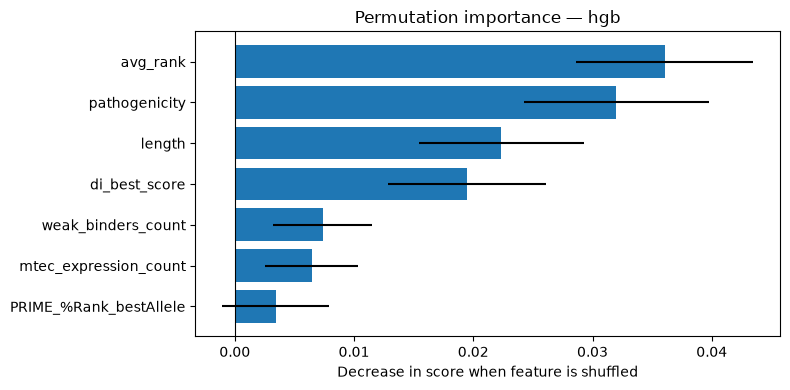

In [13]:
feature_names = FINAL_FEATURES.tolist()
print(feature_names)
 
# # Correlation
# dist_linkage, corr, clustered_names, kept_indices = plot_feature_clusters(X, feature_names)
 
# selected_idx, selected_names = select_uncorrelated_features(
#     dist_linkage, clustered_names, threshold=0.3
# )
# selected_orig_idx = [kept_indices[i] for i in selected_idx]  # map back to original X columns
# X_reduced = X[:, selected_orig_idx]  # original (unimputed) X -- pipelines handle NaNs themselves
 
# best_hgb_pipe = Pipeline([("clf", HistGradientBoostingClassifier(max_iter=100, learning_rate=0.05, max_depth=10, random_state=0))])

# hgb_importance_df = run_permutation_importance(
#     best_hgb_pipe, X_reduced, y, selected_names,
#     scoring="precision",  # match REFIT_METRIC
# )
# plot_permutation_importance(hgb_importance_df, model_name="hgb")

best_hgb_pipe = Pipeline([("clf", HistGradientBoostingClassifier(max_iter=100, learning_rate=0.05, max_depth=10, random_state=0))])

hgb_importance_df = run_permutation_importance(
    best_hgb_pipe, X, y, feature_names,
    scoring="precision",  # match REFIT_METRIC
)
plot_permutation_importance(hgb_importance_df, model_name="hgb")
 
# Optional: for a richer, directional view of HGB specifically (not a
# general cross-model method, but fast + exact for tree ensembles):
#
# import shap
# best_hgb_pipe.fit(X_reduced, y)
# explainer = shap.TreeExplainer(
#     best_hgb_pipe.named_steps["clf"], feature_perturbation="tree_path_dependent"
# )
# shap_values = explainer.shap_values(X_reduced)
# shap.summary_plot(shap_values, X_reduced, feature_names=selected_names)

# Saving Models

In [57]:
import joblib
import sklearn
import json
from datetime import datetime, timezone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

def save_metadata(pipe, filepath, trainingset: str, clf='clf', cv_results_df=None):
    metadata = {
        "sklearn_version": sklearn.__version__,
        "python_version": __import__("sys").version,
        "saved_at": datetime.now(timezone.utc).isoformat(),
        "features": list(FINAL_FEATURES),
        "params": pipe.named_steps[f"{clf}"].get_params(),
        "n_train_samples": len(X),
        "training_set" : trainingset,
    }
    if cv_results_df is not None:
        metadata["cv_results_summary"] = cv_results_df.groupby("metric")["score"].mean().to_dict()
    with open(filepath, "w") as f:
        json.dump(metadata, f, indent=2, default=str)

# print("Saving LogReg")
# final_pipe_logreg = Pipeline([
#     ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
#     ("scaler", RobustScaler()),
#     ("clf", LogisticRegression(random_state=0, max_iter=5000, class_weight="balanced", C=0.1)),
# ])
# final_pipe_logreg.fit(X, y)
# joblib.dump(final_pipe_logreg, f"{MODEL_SAVING_DIR}/logreg_pipeline_prime.joblib")
# save_metadata(final_pipe_logreg, f"{MODEL_SAVING_DIR}/logreg_pipeline_prime_metadata.json", TRAINING_SET)

# final_pipe_svm = Pipeline([
#     ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
#     ("scaler", RobustScaler()),
#     ("clf", CalibratedClassifierCV(svm.SVC(kernel="rbf", C=0.1, gamma=1, random_state=0), ensemble=False)),
# ])
# final_pipe_svm.fit(X, y)
# joblib.dump(final_pipe_svm, f"{MODEL_SAVING_DIR}/svm_rbf_pipeline.joblib")
# save_metadata(final_pipe_svm, f"{MODEL_SAVING_DIR}/svm_rbf_pipeline_metadata.json", TRAINING_SET)

#--- Random Forest ---
final_pipe_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("clf", RandomForestClassifier(max_depth=None, min_samples_leaf=1, n_estimators=500, random_state=0)),
])
print("Saving RF Model")
final_pipe_rf = pipe_rf_fixed
final_pipe_rf.fit(X, y)
joblib.dump(final_pipe_rf, f"{MODEL_SAVING_DIR}/rf_pipeline_noDIavg.joblib")
save_metadata(final_pipe_rf, f"{MODEL_SAVING_DIR}/rf_pipeline_metadata_noDIavg.json", TRAINING_SET)

# --- HistGradientBoosting ---
# final_pipe_hgb = Pipeline([
#     ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
#     ("clf", HistGradientBoostingClassifier(learning_rate=0.1, max_depth=None, max_iter=100, random_state=0)),
# ])
print("Saving HGB Model")
final_pipe_hgb = pipe_hgb_fixed
final_pipe_hgb.fit(X, y)
joblib.dump(final_pipe_hgb, f"{MODEL_SAVING_DIR}/hgb_pipeline_noDIavg.joblib")
save_metadata(final_pipe_hgb, f"{MODEL_SAVING_DIR}/hgb_pipeline_metadata_noDIavg.json", TRAINING_SET)


Saving RF Model
Saving HGB Model
